# 01. EDA: EuroCropsML Portugal

Задача проекта: по мультиспектральному спутниковому временному ряду поля определить выращиваемую сельскохозяйственную культуру.

В этом ноутбуке изучаем Portugal subset из EuroCropsML: источник, структура данных, пропуски, дубли, распределение классов, регионов и временных наблюдений. Выводы из EDA используются для baseline-модели в следующем ноутбуке.

## Источник данных

Датасет: **EuroCropsML**, Zenodo: https://zenodo.org/records/15095445.

Почему выбран:

- датасет напрямую соответствует задаче crop type classification по Sentinel-2 time series;
- содержит реальные поля и иерархические коды культур `EC_hcat_c`;
- в `raw_data.zip` страны лежат независимо: Portugal, Latvia, Estonia;
- для CP1 берём Portugal, потому что это самый компактный subset и на нём можно быстро сделать честный собственный train/validation/test split.

Самостоятельный парсинг данных: из общего `raw_data.zip` извлечены только файлы Portugal, после чего сырые временные ряды из parquet преобразуются в табличное представление для EDA и baseline.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_SEED = 42
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PORTUGAL_DIR = ROOT / "data" / "raw" / "portugal"
RAW_PATH = PORTUGAL_DIR / "raw_data" / "Portugal.parquet"
LABELS_PATH = PORTUGAL_DIR / "raw_data" / "labels" / "Portugal_labels.parquet"
IMAGES_DIR = ROOT / "report" / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)

assert RAW_PATH.exists(), f"File not found: {RAW_PATH}. Run: python -m src.raw_portugal extract"
assert LABELS_PATH.exists(), f"File not found: {LABELS_PATH}"

In [2]:
df = pd.read_parquet(RAW_PATH)
labels = pd.read_parquet(LABELS_PATH)

date_pattern = re.compile(r"^\d{4}-\d{2}-\d{2}$")
date_cols = [column for column in df.columns if date_pattern.match(str(column))]
meta_cols = [column for column in df.columns if column not in date_cols]

print(f"Portugal.parquet shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"Labels shape: {labels.shape[0]:,} rows x {labels.shape[1]:,} columns")
print(f"Metadata columns ({len(meta_cols)}): {meta_cols}")
print(f"Date columns: {len(date_cols)} from {date_cols[0]} to {date_cols[-1]}")
df.head()

Portugal.parquet shape: 100,000 rows x 225 columns
Labels shape: 100,000 rows x 3 columns
Metadata columns (6): ['parcel_id', 'EC_hcat_n', 'EC_hcat_c', 'nuts1', 'nuts2', 'nuts3']
Date columns: 219 from 2021-01-01 to 2021-12-30


,parcel_id,EC_hcat_n,EC_hcat_c,nuts1,nuts2,nuts3,2021-01-01,2021-01-02,2021-01-04,2021-01-06,...,2021-12-15,2021-12-17,2021-12-18,2021-12-20,2021-12-22,2021-12-23,2021-12-25,2021-12-27,2021-12-28,2021-12-30
0,228,grain_maize_corn_popcorn,3301010600,PT1,PT16,PT16D,None,"[1393, 1091, 908, 877, 1122, 1777, 2090, 1887,...","[1565, 1196, 998, 960, 1219, 1894, 2161, 1937,...",None,...,"[1481, 1139, 977, 781, 1177, 2269, 2635, 2460,...",None,"[1482, 1170, 1010, 840, 1214, 2187, 2595, 2450...","[6703, 6458, 5860, 6262, 6472, 6572, 6701, 656...",None,"[7087, 7249, 6843, 7519, 7686, 7950, 8281, 772...","[1915, 1546, 1264, 1073, 1274, 1933, 2165, 197...",None,"[2826, 2789, 2034, 1624, 1574, 1663, 1756, 181...","[1493, 1122, 998, 741, 1226, 2520, 2918, 2766,..."
1,363,oats,3301010500,PT1,PT16,PT16D,None,"[0, 888, 599, 379, 0, 0, 0, 950, 0, 0, 0, 0, 0]","[0, 1009, 681, 435, 0, 0, 0, 1190, 0, 0, 0, 0, 0]",None,...,"[0, 950, 623, 379, 0, 0, 0, 939, 0, 0, 0, 0, 0]",None,"[0, 1033, 712, 513, 0, 0, 0, 1016, 0, 0, 0, 0, 0]","[0, 5950, 5389, 5693, 0, 0, 0, 6026, 0, 0, 0, ...",None,"[0, 9684, 9525, 10744, 0, 0, 0, 11028, 0, 0, 0...","[0, 1549, 1235, 1070, 0, 0, 0, 1945, 0, 0, 0, ...",None,"[0, 6363, 5870, 6276, 0, 0, 0, 7213, 0, 0, 0, ...","[0, 958, 653, 411, 0, 0, 0, 1083, 0, 0, 0, 0, 0]"
2,372,vineyards_wine_vine_rebland_grapes,3303060000,PT1,PT16,PT16D,None,"[1289, 956, 749, 484, 720, 1622, 1977, 2259, 2...","[1481, 1071, 835, 549, 833, 1811, 2082, 2343, ...",None,...,"[1404, 1035, 805, 560, 831, 1625, 2123, 2260, ...",None,"[1418, 1097, 844, 654, 834, 1601, 1871, 2071, ...","[6119, 5881, 5355, 5637, 5803, 5951, 6075, 599...",None,"[9011, 9388, 9260, 10539, 10536, 11034, 11635,...","[1777, 1362, 1082, 852, 1109, 2039, 2473, 2463...",None,"[4457, 4032, 3820, 4112, 4229, 4811, 5204, 484...","[1433, 1039, 824, 537, 822, 1813, 2185, 2415, ..."
3,399,fresh_vegetables,3301070000,PT1,PT16,PT16D,None,"[0, 994, 763, 515, 843, 1780, 2050, 2134, 2297...","[0, 1092, 846, 546, 901, 1875, 2171, 2006, 239...",None,...,"[0, 1069, 901, 538, 930, 2053, 2333, 2127, 249...",None,"[0, 1089, 829, 627, 853, 1606, 1869, 1519, 202...","[0, 6306, 5712, 6077, 6260, 6421, 6560, 6408, ...",None,"[0, 9126, 8737, 9756, 9711, 10002, 10511, 1001...","[0, 1511, 1193, 991, 1111, 1611, 1808, 1624, 1...",None,"[0, 4690, 3991, 4058, 4073, 4307, 4435, 4737, ...","[0, 1077, 823, 627, 881, 1678, 1899, 1561, 205..."
4,468,other_arable_land_crops,3301990000,PT1,PT16,PT16D,None,"[1465, 1069, 935, 629, 1097, 2307, 2724, 3088,...","[1663, 1161, 1039, 671, 1257, 2645, 3071, 3383...",None,...,"[1592, 1174, 973, 803, 1156, 1821, 2063, 2096,...",None,"[1561, 1174, 949, 813, 1091, 1693, 1969, 1948,...","[6638, 6336, 5805, 6169, 6366, 6471, 6624, 647...",None,"[8712, 9013, 8696, 9668, 9742, 10048, 10453, 9...","[2059, 1714, 1371, 1193, 1315, 1730, 1953, 185...",None,"[1615, 1399, 966, 726, 768, 1049, 1157, 1145, ...","[1572, 1155, 976, 728, 1122, 2011, 2288, 2389,..."


## Структура временного ряда

Одна строка соответствует одному полю (`parcel_id`). Каждая date-column содержит либо `None`, либо список из 13 чисел Sentinel-2. Это уже агрегированный по полю временной ряд за 2021 год.

In [3]:
first_observation = next(value for value in df[date_cols].stack().values if value is not None)
print(type(first_observation), len(first_observation))
print(first_observation)

summary = pd.DataFrame({
    "value": [
        df.shape[0],
        df.shape[1],
        len(date_cols),
        len(first_observation),
        df["parcel_id"].nunique(),
        df["EC_hcat_c"].nunique(),
        df["EC_hcat_n"].nunique(),
    ]
}, index=[
    "rows_fields",
    "columns_total",
    "date_columns",
    "sentinel_values_per_date",
    "unique_parcel_id",
    "unique_EC_hcat_c",
    "unique_EC_hcat_n",
])
summary

<class 'numpy.ndarray'> 13
[1393 1091  908  877 1122 1777 2090 1887 2311  751   13 1594  885]


,value
rows_fields,100000
columns_total,225
date_columns,219
sentinel_values_per_date,13
unique_parcel_id,100000
unique_EC_hcat_c,79
unique_EC_hcat_n,79


## Типы, дубли и базовая очистка

Проверяем служебные поля, дубли по `parcel_id`, полные дубли строк и согласованность labels-файла. В baseline `parcel_id`, `EC_hcat_n` и региональные поля будут исключены из признаков, чтобы не создавать утечку через идентификатор или текстовое имя класса.

In [4]:
type_summary = df[meta_cols].dtypes.rename("dtype").to_frame()
duplicate_meta_rows = int(df[meta_cols].duplicated().sum())
duplicate_parcels = int(df["parcel_id"].duplicated().sum())
label_duplicate_parcels = int(labels["parcel_id"].duplicated().sum())
merged_labels = df[["parcel_id", "EC_hcat_c"]].merge(labels, on="parcel_id", suffixes=("_raw", "_labels"))
label_mismatch = int((merged_labels["EC_hcat_c_raw"] != merged_labels["EC_hcat_c_labels"]).sum())

print(f"Duplicated metadata rows: {duplicate_meta_rows:,}")
print(f"Duplicated parcel_id in raw: {duplicate_parcels:,}")
print(f"Duplicated parcel_id in labels: {label_duplicate_parcels:,}")
print(f"Label mismatches between raw and labels: {label_mismatch:,}")
type_summary

Duplicated metadata rows: 0
Duplicated parcel_id in raw: 0
Duplicated parcel_id in labels: 0
Label mismatches between raw and labels: 0


,dtype
parcel_id,int64
EC_hcat_n,object
EC_hcat_c,object
nuts1,object
nuts2,object
nuts3,object


## Пропуски во временных рядах

`None` в date-column означает отсутствие валидного наблюдения для поля в конкретную дату. Для baseline эти пропуски будут заменяться нулевым вектором из 13 значений. Это простая техническая очистка, не feature engineering.

Missing by date:


,missing_rate
count,219.000000
mean,0.552488
std,0.403147
min,0.000000
25%,0.000905
50%,0.708560
75%,0.946935
max,0.950430


Valid observations per field:


,valid_observations
count,100000.00000
mean,98.00514
std,34.50732
min,29.00000
25%,73.00000
50%,73.00000
75%,146.00000
max,146.00000


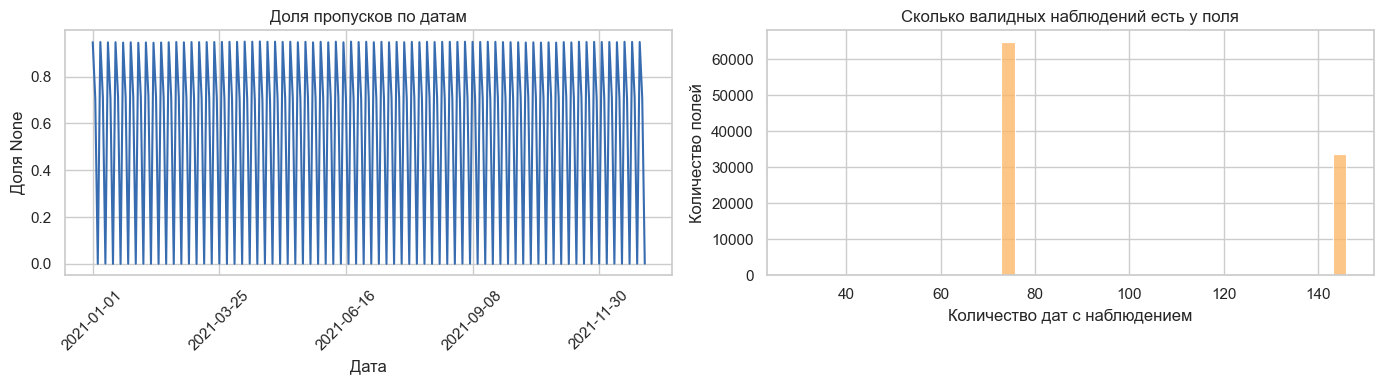

In [5]:
missing_by_date = df[date_cols].isna().mean().rename("missing_rate")
observations_per_field = df[date_cols].notna().sum(axis=1).rename("valid_observations")
missing_by_field = (1 - observations_per_field / len(date_cols)).rename("missing_rate")

print("Missing by date:")
display(missing_by_date.describe().to_frame())
print("Valid observations per field:")
display(observations_per_field.describe().to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
missing_by_date.plot(ax=axes[0], color="#386cb0")
axes[0].set_title("Доля пропусков по датам")
axes[0].set_xlabel("Дата")
axes[0].set_ylabel("Доля None")
axes[0].tick_params(axis="x", rotation=45)

sns.histplot(observations_per_field, bins=40, ax=axes[1], color="#fdb462")
axes[1].set_title("Сколько валидных наблюдений есть у поля")
axes[1].set_xlabel("Количество дат с наблюдением")
axes[1].set_ylabel("Количество полей")

plt.tight_layout()
fig.savefig(IMAGES_DIR / "eda_missingness.png", dpi=160, bbox_inches="tight")
plt.show()

## Распределение классов

Целевая переменная — `EC_hcat_c`, 10-значный код культуры. Также есть человекочитаемое имя `EC_hcat_n`. Для метрик это важно: классы сильно несбалансированы, поэтому в baseline основной метрикой будет macro F1, а не accuracy.

Number of classes: 79
Largest class share: 29.59%
Classes with < 3 samples: 13


,EC_hcat_c,EC_hcat_n,count
0,3399000000,not_known_and_other,29589
1,3303050000,olive_plantations,18712
2,3302000000,pasture_meadow_grassland_grass,16475
3,3303060000,vineyards_wine_vine_rebland_grapes,5363
4,3301010600,grain_maize_corn_popcorn,4475
5,3301090100,temporary_grass,4225
6,3303030500,sweet_chestnuts,3708
7,3301990000,other_arable_land_crops,2493
8,3306060000,oak,2108
9,3301070000,fresh_vegetables,1976


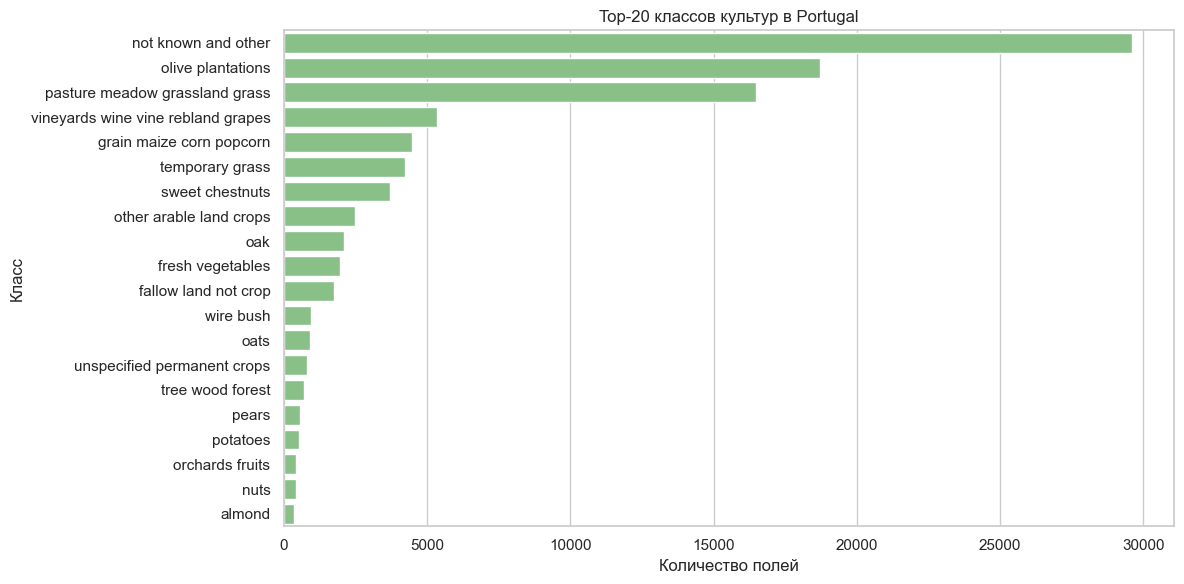

In [6]:
class_counts = (
    df.groupby(["EC_hcat_c", "EC_hcat_n"])
    .size()
    .sort_values(ascending=False)
    .rename("count")
    .reset_index()
)
print(f"Number of classes: {class_counts.shape[0]:,}")
print(f"Largest class share: {class_counts['count'].iloc[0] / len(df):.2%}")
print(f"Classes with < 3 samples: {(class_counts['count'] < 3).sum():,}")
display(class_counts.head(20))

fig, ax = plt.subplots(figsize=(12, 6))
top = class_counts.head(20).copy()
top["label"] = top["EC_hcat_n"].str.replace("_", " ").str.slice(0, 38)
sns.barplot(data=top, y="label", x="count", ax=ax, color="#7fc97f")
ax.set_title("Top-20 классов культур в Portugal")
ax.set_xlabel("Количество полей")
ax.set_ylabel("Класс")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "eda_class_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

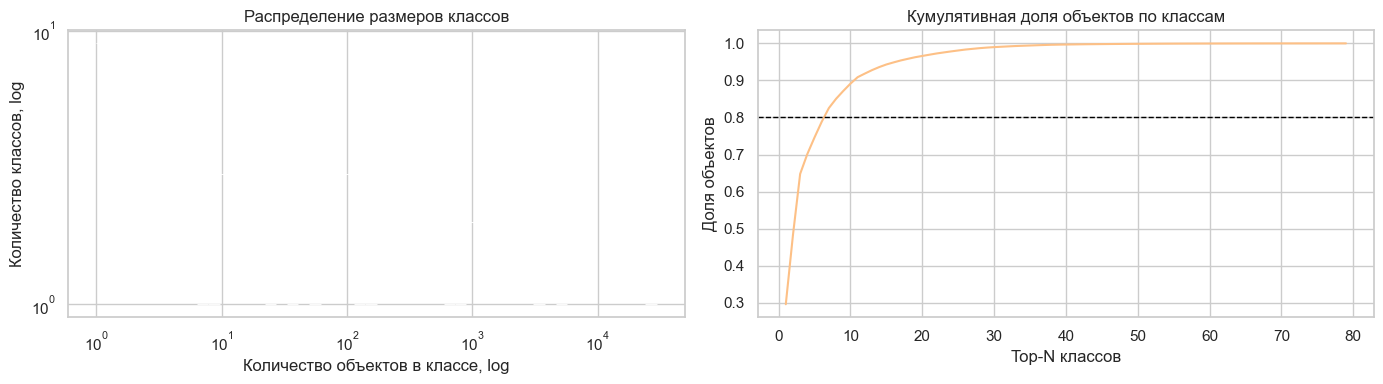

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(class_counts["count"], bins=50, log_scale=(True, True), ax=axes[0], color="#beaed4")
axes[0].set_title("Распределение размеров классов")
axes[0].set_xlabel("Количество объектов в классе, log")
axes[0].set_ylabel("Количество классов, log")

cumulative = class_counts["count"].cumsum() / class_counts["count"].sum()
axes[1].plot(np.arange(1, len(cumulative) + 1), cumulative, color="#fdc086")
axes[1].set_title("Кумулятивная доля объектов по классам")
axes[1].set_xlabel("Top-N классов")
axes[1].set_ylabel("Доля объектов")
axes[1].axhline(0.8, color="black", linestyle="--", linewidth=1)

plt.tight_layout()
fig.savefig(IMAGES_DIR / "eda_class_imbalance.png", dpi=160, bbox_inches="tight")
plt.show()

## География: NUTS-регионы

Геометрии для baseline не используем, но региональные поля позволяют проверить, насколько данные сконцентрированы в отдельных частях Portugal. В baseline `nuts1`, `nuts2`, `nuts3` исключаются из признаков, чтобы модель не училась на региональном идентификаторе вместо временного ряда.

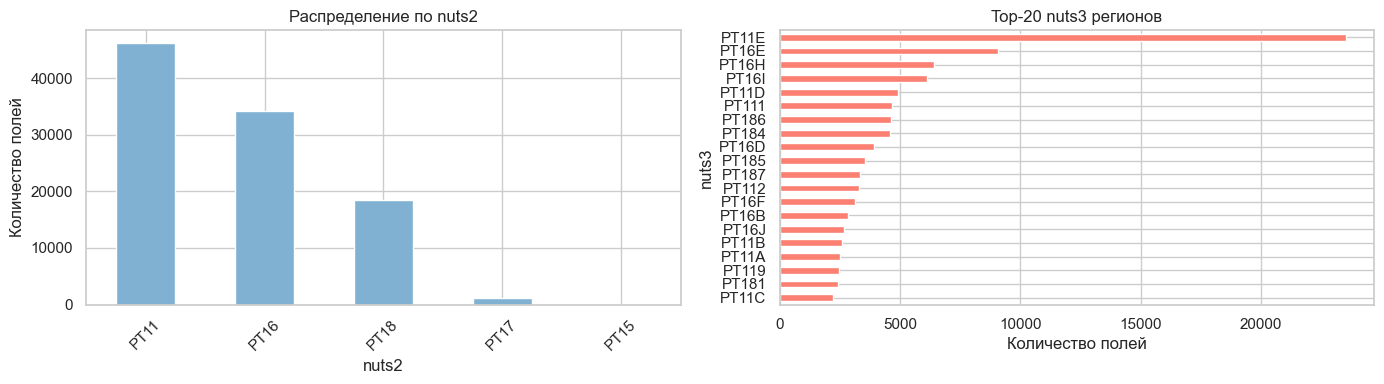

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df["nuts2"].value_counts().sort_values(ascending=False).plot(kind="bar", ax=axes[0], color="#80b1d3")
axes[0].set_title("Распределение по nuts2")
axes[0].set_xlabel("nuts2")
axes[0].set_ylabel("Количество полей")
axes[0].tick_params(axis="x", rotation=45)

df["nuts3"].value_counts().head(20).sort_values().plot(kind="barh", ax=axes[1], color="#fb8072")
axes[1].set_title("Top-20 nuts3 регионов")
axes[1].set_xlabel("Количество полей")
axes[1].set_ylabel("nuts3")

plt.tight_layout()
fig.savefig(IMAGES_DIR / "eda_regions.png", dpi=160, bbox_inches="tight")
plt.show()

## Спектральные значения и выбросы

Для первичной проверки берём выборку строк и раскрываем списки из 13 значений. Нулевые значения встречаются в данных; для baseline они не удаляются, потому что без предметной разметки сложно уверенно отделить технический ноль от валидного значения. Потенциальные выбросы оцениваем по квантилям каналов.

In [9]:
BAND_NAMES = [f"band_{idx:02d}" for idx in range(13)]
sample = df.sample(n=min(5_000, len(df)), random_state=RANDOM_SEED)

band_values = []
for column in date_cols:
    values = sample[column].dropna().tolist()
    if values:
        band_values.append(np.asarray(values, dtype=np.float32))

bands = np.vstack(band_values)
band_df = pd.DataFrame(bands, columns=BAND_NAMES)
quantiles = band_df.quantile([0, 0.01, 0.25, 0.5, 0.75, 0.99, 1]).T
quantiles

,0.00,0.01,0.25,0.50,0.75,0.99,1.00
band_00,0.0,0.0,0.0,1188.0,1607.0,8343.06,14809.0
band_01,0.0,744.0,993.0,1223.0,3431.0,8806.06,15318.0
band_02,0.0,550.0,891.0,1160.0,3150.0,8376.00,15602.0
band_03,0.0,345.0,716.0,1168.0,3243.0,8980.06,18259.0
band_04,0.0,0.0,1020.0,1412.0,3166.0,9005.00,18571.0
band_05,0.0,0.0,1816.0,2371.0,3682.0,9175.06,19190.0
band_06,0.0,0.0,2114.0,2763.0,4062.0,9402.00,19928.0
band_07,0.0,608.0,2181.0,2794.0,4082.0,9199.00,19047.0
band_08,0.0,0.0,2350.0,3051.0,4301.0,9499.00,20488.0
band_09,0.0,0.0,0.0,589.0,1088.0,5577.00,12750.0


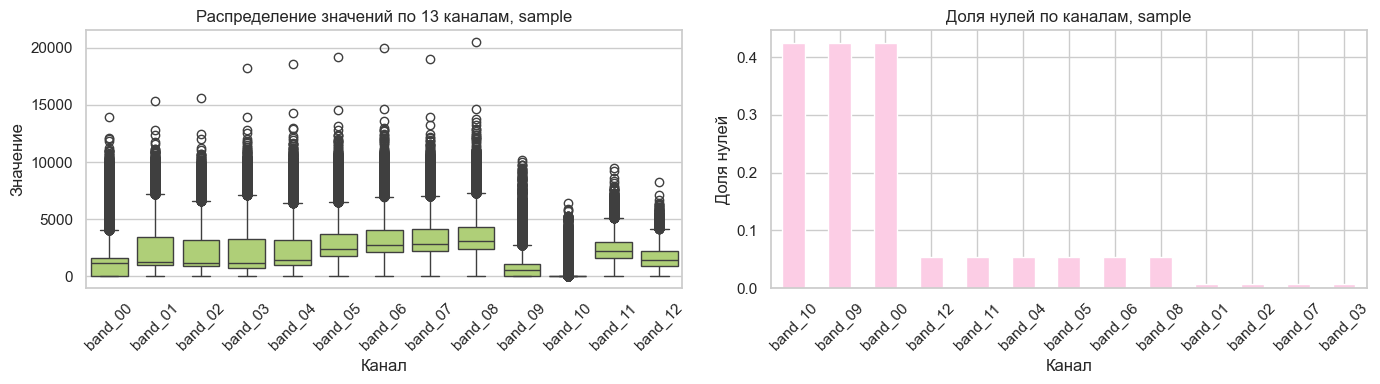

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=band_df.sample(n=min(20_000, len(band_df)), random_state=RANDOM_SEED), ax=axes[0], color="#b3de69")
axes[0].set_title("Распределение значений по 13 каналам, sample")
axes[0].set_xlabel("Канал")
axes[0].set_ylabel("Значение")
axes[0].tick_params(axis="x", rotation=45)

zero_share = (band_df == 0).mean().sort_values(ascending=False)
zero_share.plot(kind="bar", ax=axes[1], color="#fccde5")
axes[1].set_title("Доля нулей по каналам, sample")
axes[1].set_xlabel("Канал")
axes[1].set_ylabel("Доля нулей")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
fig.savefig(IMAGES_DIR / "eda_band_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

## Средние временные профили top-классов

Для наглядности считаем среднее значение по 13 каналам в каждую дату и сравниваем top-5 культур. Это не используется как feature engineering в baseline, только помогает увидеть различия временной динамики.

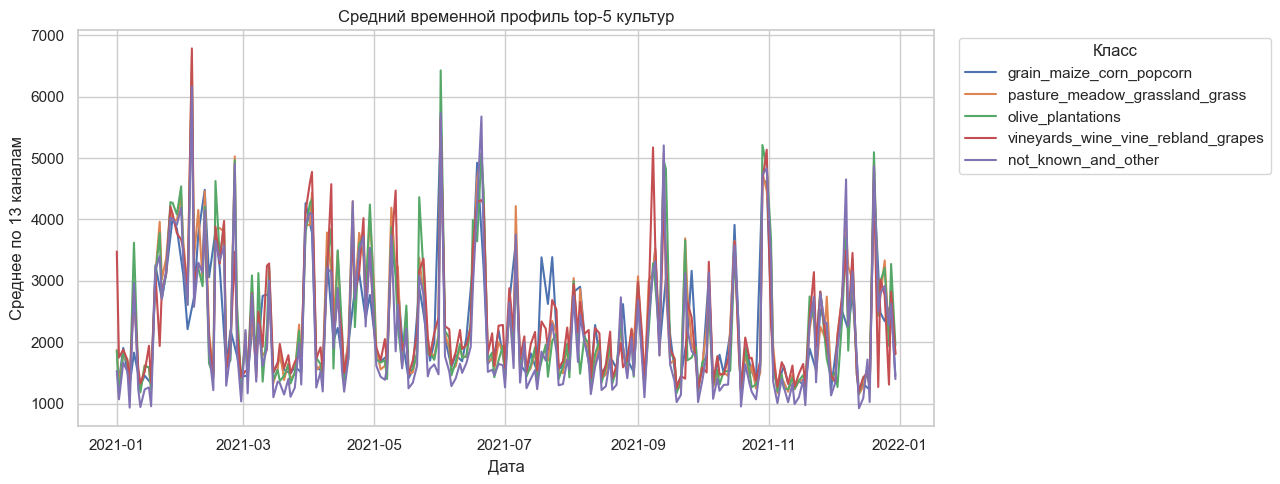

In [11]:
def mean_reflectance(value):
    if value is None:
        return np.nan
    arr = np.asarray(value, dtype=np.float32)
    return float(np.nanmean(arr))

profile_classes = class_counts.head(5)["EC_hcat_c"].tolist()
profile_sample = df[df["EC_hcat_c"].isin(profile_classes)].sample(
    n=min(2_000, df[df["EC_hcat_c"].isin(profile_classes)].shape[0]),
    random_state=RANDOM_SEED,
)

profile_rows = []
for crop_code, group in profile_sample.groupby("EC_hcat_c"):
    crop_name = group["EC_hcat_n"].iloc[0]
    means = [group[column].map(mean_reflectance).mean() for column in date_cols]
    profile_rows.extend(
        {"date": pd.to_datetime(date), "mean_reflectance": value, "crop": crop_name}
        for date, value in zip(date_cols, means, strict=True)
    )
profile_df = pd.DataFrame(profile_rows)

fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(data=profile_df, x="date", y="mean_reflectance", hue="crop", ax=ax)
ax.set_title("Средний временной профиль top-5 культур")
ax.set_xlabel("Дата")
ax.set_ylabel("Среднее по 13 каналам")
ax.legend(title="Класс", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(IMAGES_DIR / "eda_temporal_profiles.png", dpi=160, bbox_inches="tight")
plt.show()

## Выводы EDA

- Portugal subset достаточно большой для CP1: 100 000 полей и 225 колонок, из них 219 дат с временными наблюдениями.
- Одна строка — одно поле, поэтому корректный split нужно делать по строкам/полям; нельзя дробить отдельные даты одного поля между train и test.
- Целевая переменная `EC_hcat_c` многоклассовая и несбалансированная: accuracy будет завышать качество на частых культурах, поэтому основной метрикой выбираем macro F1. Balanced accuracy оставляем дополнительной метрикой.
- Во временных рядах много пропусков `None`; для baseline без feature engineering используем простую замену отсутствующего наблюдения нулевым 13-мерным вектором.
- `parcel_id`, `EC_hcat_n`, `nuts1`, `nuts2`, `nuts3` исключаются из признаков, чтобы избежать data leakage через идентификаторы, название класса или регион.
- Для baseline признаки получаются прямым разворачиванием исходных временных рядов: `date x band`. Новые доменные признаки вроде NDVI пока не создаются.